<a href="https://colab.research.google.com/github/SolisProcopioUriel/SimulacionII/blob/main/Crecimiento_tumoral_V3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Importar biblotecas necesarias

In [ ]:
import pandas as pd
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import Sequential
from keras.layers import Input, Dense
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#Preparación de los datos

In [ ]:
datos = pd.read_excel('Datos_Tumoral_V3.xlsx')
filas_a_eliminar = [0, 91, 46, 96, 97, 98, 143, 148]
datos = datos.drop(filas_a_eliminar, axis=0).reset_index(drop=True)
datos

,Tabla 1,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10
0,117_11,196,359,417.0,419.0,423.0,653.0,729.0,797.0,944.0,1.0
1,117_7,164,196,223.0,247.0,375.0,871.0,880.0,985.0,1008.0,1.0
2,117_42,163,306,373.0,661.0,915.0,1018.0,1621.0,1855.0,2479.0,1.0
3,117_3,118,128,148.0,222.0,454.0,487.0,642.0,962.0,1261.0,1.0
4,117_36,117,140,204.0,390.0,411.0,656.0,821.0,1097.0,1197.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
184,675_25,140,152,175.0,175.0,209.0,448.0,653.0,686.0,785.0,5.0
185,675_50,125,148,159.0,427.0,486.0,578.0,908.0,963.0,1195.0,5.0
186,675_45,100,101,186.0,242.0,410.0,432.0,580.0,644.0,748.0,5.0
187,675_28,81,89,126.0,132.0,136.0,197.0,260.0,261.0,290.0,5.0


In [ ]:
#datos = pd.read_excel('Datos_Tumoral_V2.xlsx')
#datos = datos.drop([0])
#datos = datos.drop([91])
#datos = datos.drop([46])
#datos = datos.drop([96])
#datos = datos.drop([97])
#datos = datos.drop([98])
#datos = datos.drop([143])
#datos

# Separar datos en características $X$ y etiquetas $y$

In [ ]:
X = datos.iloc[:, 1:10]
y = datos.iloc[:, 10]
#X
#y

In [ ]:
y_tf = tf.keras.utils.to_categorical(y - 1, num_classes=5)
#y_tf

#Configuración del modelo

In [ ]:
modelo = Sequential()
modelo.add(Input(shape=(9,)))
modelo.add(Dense(64, activation='tanh'))
modelo.add(Dense(128, activation='relu'))
#modelo.add(Dense(128, activation='tanh'))
#modelo.add(Dense(16, activation='relu'))
#modelo.add(Dense(16, activation='relu'))
modelo.add(Dense(5, activation='softmax'))
modelo.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,605 (37.52 KB)

 Trainable params: 9,605 (37.52 KB)

 Non-trainable params: 0 (0.00 B)

#Optimizador, función de perdida

In [ ]:
optimizador = tf.keras.optimizers.Adam(learning_rate=0.000795)
modelo.compile(optimizer=optimizador, loss='categorical_crossentropy', metrics=['accuracy'])

#lr = 0.001496
#lr = 0.006424
#lr = 0.009885
#lr = 0.005595
#lr = 0.000857
#lr = 0.001173
#lr = 0.000795
#loss = kl_divergence
#loss = categorical_crossentropy

#Entrenamiento del modelo

In [ ]:
X = np.array(X, dtype=np.float32)
y_tf = np.array(y_tf, dtype=np.float32)

In [ ]:
modelo.fit(X, y_tf, epochs=200)

Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1822 - loss: 1.7505
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5681 - loss: 1.3656 
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5447 - loss: 1.2263 
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5847 - loss: 1.1150 
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6254 - loss: 0.9957 
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6411 - loss: 0.9946 
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6795 - loss: 0.9494
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6494 - loss: 0.9282 
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6936 - loss: 0.8652 
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6901 - loss: 0.9104 
Epoch 11/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6719 - loss: 0.8592 
Epoch 12/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6897 - loss

#Evaluación del modelo mediante matriz de confución

In [ ]:
predicciones = modelo.predict(X)
#print(predicciones.shape)
#print(np.round(predicciones[0], 3))
y_pred = np.argmax(predicciones, axis=1) + 1
cm = confusion_matrix(y, y_pred)
#print(cm)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


Matriz de confución

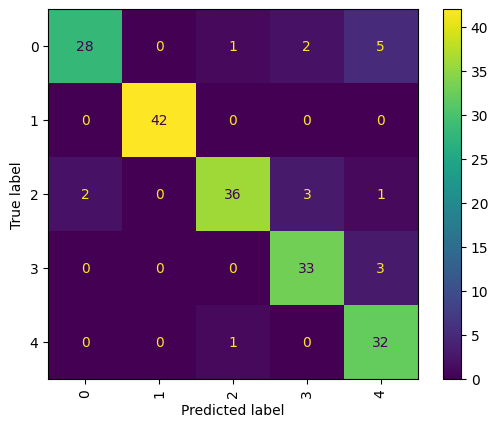

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(xticks_rotation='vertical')
plt.show()